In [1]:
# =============================================================================
# DKTC 위협 대화 분류 — 규칙 기반 후처리(Logit Adjustment) 분석 v3
#
# 기반: v2 노트북 + v3 수정 반영
#
# v3 핵심 변경:
#   1) margin threshold 완화: 0.15 -> 0.30
#   2) boost ratio 상향: 0.6 -> 1.0
#   3) top2 -> top3 후보 허용
#   4) 동점이면 완전 중단하지 않고 top1/top2 내부면 약한 tie-break 허용
#
# 타겟 혼동축:
#   - 협박(0) ↔ 갈취(1)
#   - 기타괴롭힘(3) ↔ 갈취(1)
#   - 직장내괴롭힘(2) ↔ 기타괴롭힘(3)
#
# 환경: Docker (py-gpu-env), RTX 5060 Ti 16GB, Python 3.10
# =============================================================================

In [2]:
# ============================================================================
# 00. 환경 설정 및 최적화
# ============================================================================
import sys, site, os, glob
print("sys.executable =", sys.executable)
print("sys.prefix     =", sys.prefix)
print("site-packages  =", site.getsitepackages())
 
import transformers, datasets, evaluate, huggingface_hub, accelerate
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)
 
 
# %%
import os, time, gc, warnings, json, re
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
 
# 재현성
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
 
from datasets import Dataset, DatasetDict
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from collections import Counter
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
 
# --- CPU / GPU 최적화 ---
CPU_COUNT = os.cpu_count() or 4
CPU_THREADS = max(1, CPU_COUNT // 2)
 
os.environ["OMP_NUM_THREADS"] = str(CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(CPU_THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "true"
 
torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(max(1, min(4, CPU_THREADS // 2)))
except RuntimeError:
    pass
 
USE_CUDA = torch.cuda.is_available()
DEVICE = "cuda" if USE_CUDA else "cpu"
 
if USE_CUDA:
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
 
print("=" * 70)
print(f"PyTorch              : {torch.__version__}")
print(f"CUDA available       : {USE_CUDA}")
print(f"Device               : {DEVICE}")
print(f"CPU count            : {CPU_COUNT}")
print(f"CPU threads          : {CPU_THREADS}")
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    free_mem, total_mem = torch.cuda.memory.mem_get_info(0)

    print(f"GPU name             : {props.name}")
    print(f"GPU count            : {torch.cuda.device_count()}")
    print(f"GPU memory(total)    : {props.total_memory / (1024**3):.2f} GB")
    print(f"GPU memory(free)     : {free_mem / (1024**3):.2f} GB")
print("=" * 70)

sys.executable = /usr/bin/python3
sys.prefix     = /usr
site-packages  = ['/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.10/dist-packages']


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers: 5.3.0
datasets: 4.8.2
evaluate: 0.4.6
huggingface_hub: 1.7.1
accelerate: 1.13.0
PyTorch              : 2.10.0+cu128
CUDA available       : True
Device               : cuda
CPU count            : 20
CPU threads          : 10
GPU name             : NVIDIA GeForce RTX 5060 Ti
GPU count            : 1
GPU memory(total)    : 15.93 GB
GPU memory(free)     : 14.80 GB


In [3]:
# ============================================================================
# 01. 데이터 로드 + 토크나이징
# ============================================================================
MODEL_NAME = "klue/roberta-base"
MAX_LENGTH = 512
NUM_LABELS = 5

LABEL_NAMES = ["협박", "갈취", "직장내괴롭힘", "기타괴롭힘", "일반대화"]
LABEL2ID = {name: idx for idx, name in enumerate(LABEL_NAMES)}

# --- 전처리된 CSV 로드 ---
train_df = pd.read_csv("data/train_processed_260317_n_1000.csv")
val_df = pd.read_csv("data/val_processed_260317_n_1000.csv")

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Classes: {NUM_LABELS}")
print(f"\n검증 클래스 분포:")
print(val_df["label_name"].value_counts().to_string())

# --- 토크나이저 ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# --- Hugging Face Dataset 변환 ---
raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)
    ),
    "validation": Dataset.from_pandas(
        val_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)
    ),
})

def preprocess_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False)

tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    batch_size=1000,
    num_proc=max(1, min(8, CPU_THREADS)),
    remove_columns=["text"],
    desc="Tokenizing",
)
tokenized_datasets.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if USE_CUDA else None,
    return_tensors="pt",
)

# --- 원본 텍스트 배열 (규칙 적용에 필요) ---
val_texts = val_df["text"].astype(str).values
val_true_labels = val_df["label"].values

print(f"\n토크나이징 완료 — 원본 텍스트 {len(val_texts)}개 보존")


Train: 3942, Val: 969, Classes: 5

검증 클래스 분포:
label_name
기타 괴롭힘 대화      202
일반 대화          200
갈취 대화          195
직장 내 괴롭힘 대화    194
협박 대화          178


Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (num_proc=8): 100%|██████████| 3942/3942 [00:00<00:00, 7728.30 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (num_proc=8): 100%|██████████| 969/969 [00:00<00:00, 2871.39 examples/s]


토크나이징 완료 — 원본 텍스트 969개 보존


In [4]:
# ============================================================================
# 02. 모델 로드 + Raw Logit / Prob / Margin 추출
# ============================================================================
import os
import glob
import gc
import numpy as np
import torch
import evaluate as ev

from sklearn.metrics import f1_score
from transformers import AutoModelForSequenceClassification, Trainer

# 아래 둘 중 하나만 사용하세요.
# 1) 결과 디렉터리 지정: 내부의 최신 checkpoint 자동 선택
CHECKPOINT_DIR = "./results_dktc_focal_epoch_5"

# 2) 특정 checkpoint 직접 지정 시 아래 값을 사용하고 CHECKPOINT_DIR는 무시됨
CHECKPOINT_PATH = None
# 예: "./results_dktc_focal_epoch_5/checkpoint-741"

# ----------------------------------------------------------------------------
# checkpoint 경로 결정
# ----------------------------------------------------------------------------
if CHECKPOINT_PATH is not None:
    model_path = CHECKPOINT_PATH
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"지정한 CHECKPOINT_PATH가 존재하지 않습니다: {model_path}")
    print(f"직접 경로 사용: {model_path}")
else:
    if not os.path.exists(CHECKPOINT_DIR):
        raise FileNotFoundError(f"CHECKPOINT_DIR가 존재하지 않습니다: {CHECKPOINT_DIR}")

    ckpt_candidates = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "checkpoint-*")))
    if not ckpt_candidates:
        raise FileNotFoundError(
            f"checkpoint-* 폴더를 찾지 못했습니다: {CHECKPOINT_DIR}"
        )

    model_path = ckpt_candidates[-1]
    print(f"최신 체크포인트 사용: {model_path}")

# ----------------------------------------------------------------------------
# 모델 로드
# ----------------------------------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=NUM_LABELS
)
model.eval()

if USE_CUDA:
    model = model.to(DEVICE)

# ----------------------------------------------------------------------------
# Trainer로 raw logits 추출
# ----------------------------------------------------------------------------
acc_metric = ev.load("accuracy")
f1_metric  = ev.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_weighted": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }

trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\nValidation 추론 시작...")
val_result = trainer.predict(tokenized_datasets["validation"])

# ----------------------------------------------------------------------------
# raw logits / labels
# ----------------------------------------------------------------------------
raw_logits = val_result.predictions      # shape: (N, NUM_LABELS)
val_labels = val_result.label_ids        # shape: (N,)

# ----------------------------------------------------------------------------
# logits -> probs
# ----------------------------------------------------------------------------
probs = torch.softmax(
    torch.tensor(raw_logits, dtype=torch.float32),
    dim=-1
).cpu().numpy()

# ----------------------------------------------------------------------------
# sanity check 1: argmax(logits) == argmax(probs)
# ----------------------------------------------------------------------------
preds_from_logits = np.argmax(raw_logits, axis=-1)
preds_from_probs = np.argmax(probs, axis=-1)

assert np.array_equal(preds_from_logits, preds_from_probs), \
    "FATAL: argmax(logits) != argmax(softmax(logits))"

# ----------------------------------------------------------------------------
# sanity check 2: 각 행의 확률합 = 1
# ----------------------------------------------------------------------------
row_sums = probs.sum(axis=1)
assert np.allclose(row_sums, 1.0, atol=1e-6), \
    "FATAL: softmax 확률합이 1이 아닙니다."

# ----------------------------------------------------------------------------
# 기본 성능 (후처리 전)
# ----------------------------------------------------------------------------
baseline_preds = preds_from_logits.copy()

baseline_acc = np.mean(baseline_preds == val_labels)
baseline_f1_macro = f1_score(val_labels, baseline_preds, average="macro")
baseline_f1_weighted = f1_score(val_labels, baseline_preds, average="weighted")

print(f"\n후처리 전 성능 (모델 원본)")
print(f"  Accuracy      : {baseline_acc:.4f}")
print(f"  Macro F1      : {baseline_f1_macro:.4f}")
print(f"  Weighted F1   : {baseline_f1_weighted:.4f}")
print(f"  오분류 건수    : {(baseline_preds != val_labels).sum()} / {len(val_labels)}")

print(f"\nRaw logits shape : {raw_logits.shape}")
print(f"Prob shape       : {probs.shape}")
print(f"Prob 합계 검증(첫 5개): {row_sums[:5]}")

# ----------------------------------------------------------------------------
# logit gap 통계 (top1 - top2)
# ----------------------------------------------------------------------------
sorted_logits = np.sort(raw_logits, axis=-1)[:, ::-1]
logit_gaps = sorted_logits[:, 0] - sorted_logits[:, 1]

print(f"\nLogit gap (top1-top2) 통계")
print(f"  mean   : {logit_gaps.mean():.3f}")
print(f"  median : {np.median(logit_gaps):.3f}")
print(f"  std    : {logit_gaps.std():.3f}")
print(f"  p10    : {np.percentile(logit_gaps, 10):.3f}")
print(f"  p25    : {np.percentile(logit_gaps, 25):.3f}")
print(f"  p50    : {np.percentile(logit_gaps, 50):.3f}")
print(f"  p75    : {np.percentile(logit_gaps, 75):.3f}")
print(f"  p90    : {np.percentile(logit_gaps, 90):.3f}")

# ----------------------------------------------------------------------------
# probability margin 통계 (top1 prob - top2 prob)
# ----------------------------------------------------------------------------
sorted_probs = np.sort(probs, axis=-1)[:, ::-1]
top1_probs = sorted_probs[:, 0]
top2_probs = sorted_probs[:, 1]
prob_margins = top1_probs - top2_probs

print(f"\nProb margin (top1-top2) 통계")
print(f"  mean   : {prob_margins.mean():.4f}")
print(f"  median : {np.median(prob_margins):.4f}")
print(f"  std    : {prob_margins.std():.4f}")
print(f"  p10    : {np.percentile(prob_margins, 10):.4f}")
print(f"  p25    : {np.percentile(prob_margins, 25):.4f}")
print(f"  p50    : {np.percentile(prob_margins, 50):.4f}")
print(f"  p75    : {np.percentile(prob_margins, 75):.4f}")
print(f"  p90    : {np.percentile(prob_margins, 90):.4f}")

# ----------------------------------------------------------------------------
# 후처리 실험용 DataFrame
# ----------------------------------------------------------------------------
import pandas as pd

df_post = pd.DataFrame({
    "true_label": val_labels,
    "pred_label": baseline_preds,
    "correct": baseline_preds == val_labels,
    "top1_prob": top1_probs,
    "top2_prob": top2_probs,
    "prob_margin": prob_margins,
    "logit_gap": logit_gaps,
})

# 클래스별 raw logits / probs도 같이 저장
for i in range(NUM_LABELS):
    df_post[f"logit_{i}"] = raw_logits[:, i]
    df_post[f"prob_{i}"] = probs[:, i]

print("\n후처리용 df_post 생성 완료")
print(df_post.head())

# ----------------------------------------------------------------------------
# 메모리 해제
# ----------------------------------------------------------------------------
del model, trainer
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

print("\nLogit / Prob / Margin 추출 완료 — 모델 메모리 해제")

최신 체크포인트 사용: ./results_dktc_focal_epoch_5/checkpoint-741


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2092.01it/s]



Validation 추론 시작...



후처리 전 성능 (모델 원본)
  Accuracy      : 0.9298
  Macro F1      : 0.9301
  Weighted F1   : 0.9302
  오분류 건수    : 68 / 969

Raw logits shape : (969, 5)
Prob shape       : (969, 5)
Prob 합계 검증(첫 5개): [1.         1.         0.99999994 1.0000001  0.99999994]

Logit gap (top1-top2) 통계
  mean   : 3.136
  median : 3.262
  std    : 1.121
  p10    : 1.458
  p25    : 2.573
  p50    : 3.262
  p75    : 3.982
  p90    : 4.545

Prob margin (top1-top2) 통계
  mean   : 0.8283
  median : 0.8922
  std    : 0.1908
  p10    : 0.5896
  p25    : 0.8281
  p50    : 0.8922
  p75    : 0.9351
  p90    : 0.9585

후처리용 df_post 생성 완료
   true_label  pred_label  correct  top1_prob  top2_prob  prob_margin  \
0           3           3     True   0.656812   0.230019     0.426794   
1           3           3     True   0.922853   0.033267     0.889586   
2           1           1     True   0.915364   0.049302     0.866062   
3           2           2     True   0.947200   0.023518     0.923681   
4           1           1     Tru

In [5]:
# ============================================================================
# 03. 타겟 혼동축 정의 + 경계 샘플 분석
# ============================================================================
TARGET_CONFUSION_AXES = {
    frozenset({0, 1}),   # 협박 ↔ 갈취
    frozenset({1, 3}),   # 갈취 ↔ 기타괴롭힘
    frozenset({2, 3}),   # 직장내괴롭힘 ↔ 기타괴롭힘
}

print("타겟 혼동축:")
for axis in TARGET_CONFUSION_AXES:
    ids = sorted(axis)
    print(f"  {LABEL_NAMES[ids[0]]} ↔ {LABEL_NAMES[ids[1]]}")

# --- margin 분포 ---
sorted_probs = np.sort(probs, axis=-1)[:, ::-1]
margins = sorted_probs[:, 0] - sorted_probs[:, 1]

print(f"\nMargin 분포 통계:")
print(f"  mean    : {margins.mean():.4f}")
print(f"  median  : {np.median(margins):.4f}")
print(f"  std     : {margins.std():.4f}")

타겟 혼동축:
  협박 ↔ 갈취
  갈취 ↔ 기타괴롭힘
  직장내괴롭힘 ↔ 기타괴롭힘

Margin 분포 통계:
  mean    : 0.8283
  median  : 0.8922
  std     : 0.1908


In [6]:
# --- 타겟 혼동축 해당 여부별 분석 ---
top2_classes = np.argsort(probs, axis=-1)[:, -2:]
top2_sets = [frozenset(row.tolist()) for row in top2_classes]

on_target_mask = np.array([s in TARGET_CONFUSION_AXES for s in top2_sets])

ANALYSIS_THRESHOLD = 0.20
boundary_mask = margins < ANALYSIS_THRESHOLD

both_mask = boundary_mask & on_target_mask
boundary_only = boundary_mask & ~on_target_mask
target_only = ~boundary_mask & on_target_mask
non_boundary_non_target = ~boundary_mask & ~on_target_mask

print(f"\n4분면 분석 (threshold={ANALYSIS_THRESHOLD}):")
print(f"  경계 + 타겟 혼동축 (= 보정 대상) : {both_mask.sum():4d}건 "
      f"(오분류 {(baseline_preds[both_mask] != val_labels[both_mask]).sum()}건)")
print(f"  경계 + 비타겟                   : {boundary_only.sum():4d}건 "
      f"(오분류 {(baseline_preds[boundary_only] != val_labels[boundary_only]).sum()}건)")
print(f"  비경계 + 타겟 혼동축            : {target_only.sum():4d}건 "
      f"(오분류 {(baseline_preds[target_only] != val_labels[target_only]).sum()}건)")
print(f"  비경계 + 비타겟                 : {non_boundary_non_target.sum():4d}건")

if both_mask.sum() > 0:
    target_wrong = both_mask & (baseline_preds != val_labels)
    print(f"\n보정 대상 내 오분류 패턴 (실제→예측):")
    wrong_pairs = list(zip(val_labels[target_wrong], baseline_preds[target_wrong]))
    for (tc, pc), cnt in Counter(wrong_pairs).most_common(10):
        print(f"  {LABEL_NAMES[tc]:10s} → {LABEL_NAMES[pc]:10s}: {cnt}건")


4분면 분석 (threshold=0.2):
  경계 + 타겟 혼동축 (= 보정 대상) :   21건 (오분류 7건)
  경계 + 비타겟                   :    7건 (오분류 1건)
  비경계 + 타겟 혼동축            :  594건 (오분류 45건)
  비경계 + 비타겟                 :  347건

보정 대상 내 오분류 패턴 (실제→예측):
  갈취         → 협박        : 1건
  협박         → 기타괴롭힘     : 1건
  기타괴롭힘      → 협박        : 1건
  갈취         → 기타괴롭힘     : 1건
  직장내괴롭힘     → 기타괴롭힘     : 1건
  기타괴롭힘      → 갈취        : 1건
  협박         → 갈취        : 1건


In [9]:
# ============================================================================
# 04. 키워드 사전 정의 v3 (사전 자체는 v2 precision 중심 유지)
# ============================================================================
KEYWORD_RULES = {
    "협박": [
        r"죽[이여일]",
        r"가만.*안.*[두둬]",
        r"해코지|보복",
        r"때려.*[죽줄]|패[줘주].*죽",
        r"불[질태].*[워러]",
    ],
    "갈취": [
        r"돈.*[내놔]",
        r"[내놔줘].*가져",
        r"입금.*[해하안]|송금.*[해하]",
        r"카드.*[줘놔빌]",
        r"[갚물]어.*[내놔]",
    ],
    "직장내괴롭힘": [
        r"(상사|팀장|부장|과장|대리).{0,15}(무시|막말|폭언|갑질)",
        r"(회사|직장|사무실).{0,15}(따돌|왕따|배제|무시)",
        r"(퇴사|해고|짤[려리]).{0,10}(협박|위협|으름)",
        r"(업무|보고|회의).{0,10}(배제|제외|빼)",
        r"(승진|평가|인사).{0,10}(불이익|차별|보복)",
    ],
    "기타괴롭힘": [
        r"왕따|은따|전따",
        r"따돌[려리림]",
        r"놀림.*[당받]",
    ],
}

COMPILED_RULES = {}
for class_name, patterns in KEYWORD_RULES.items():
    class_id = LABEL2ID[class_name]
    COMPILED_RULES[class_id] = [re.compile(p) for p in patterns]

print("키워드 규칙 v3 정의 완료")
for class_name, patterns in KEYWORD_RULES.items():
    print(f"  {class_name:10s}: {len(patterns)}개 패턴")


def count_rule_hits_for_class(text, class_id):
    if class_id not in COMPILED_RULES:
        return 0
    text = str(text)
    return sum(1 for pattern in COMPILED_RULES[class_id] if pattern.search(text))


def count_keyword_hits(text, class_id):
    return count_rule_hits_for_class(text, class_id)

키워드 규칙 v3 정의 완료
  협박        : 5개 패턴
  갈취        : 5개 패턴
  직장내괴롭힘    : 5개 패턴
  기타괴롭힘     : 3개 패턴


In [ ]:
# ============================================================================
# 05. v3 후처리 함수
# ============================================================================
def apply_rule_postprocessing_v3(
    logits,
    texts,
    margin_threshold=0.35,
    boost_ratio=1.0,
    topk_candidates=3,
    tie_break_boost=0.5,
    target_axes=TARGET_CONFUSION_AXES,
):
    """
    v3 규칙 후처리

    Gate 1. 확률 margin이 작은 샘플만 후보
    Gate 2. top1-top2가 target confusion axis 안에 있을 때만 후보
    Gate 3. topk(top3) 안에서 규칙 hit가 있는 클래스만 후보
    Gate 4. 규칙 hit 최다 클래스에 logit boost 적용
            - 단독 1위면 정상 boost
            - 동점이면 top1/top2 내부 클래스 하나만 남을 때 약한 tie-break boost
    """
    assert logits.ndim == 2, "logits shape must be (N, C)"
    assert len(logits) == len(texts), "logits와 texts 길이가 다릅니다."
    assert topk_candidates >= 2, "topk_candidates는 최소 2 이상이어야 합니다."
    assert 0.0 <= tie_break_boost <= 1.0, "tie_break_boost는 0~1 범위가 적절합니다."

    adjusted_logits = logits.copy()
    adjusted_preds = np.argmax(logits, axis=1).copy()

    logits_max = logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits - logits_max)
    probs_local = exp_logits / exp_logits.sum(axis=1, keepdims=True)

    log = {
        "n_total": len(texts),
        "n_gate1_margin": 0,
        "n_gate2_axis": 0,
        "n_gate3_rule_hit": 0,
        "n_candidate_hit": 0,
        "n_changed": 0,
        "changed_cases": [],
    }

    for i, text in enumerate(texts):
        sample_logits = adjusted_logits[i].copy()
        sample_probs = probs_local[i]

        topk_idx = np.argsort(sample_probs)[-topk_candidates:][::-1]
        top1 = int(topk_idx[0])
        top2 = int(topk_idx[1])

        margin = float(sample_probs[top1] - sample_probs[top2])
        if margin >= margin_threshold:
            continue
        log["n_gate1_margin"] += 1

        top_pair = frozenset({top1, top2})
        if top_pair not in target_axes:
            continue
        log["n_gate2_axis"] += 1

        hits = {}
        for cls in topk_idx:
            cls = int(cls)
            n_hit = count_rule_hits_for_class(text, cls)
            if n_hit > 0:
                hits[cls] = n_hit

        if not hits:
            continue
        log["n_gate3_rule_hit"] += 1

        max_hit = max(hits.values())
        best_classes = [cls for cls, hit in hits.items() if hit == max_hit]

        if len(best_classes) == 1:
            target_class = best_classes[0]
            effective_ratio = boost_ratio
        else:
            tied_top = [c for c in best_classes if c in {top1, top2}]
            if len(tied_top) == 1:
                target_class = tied_top[0]
                effective_ratio = boost_ratio * tie_break_boost
            else:
                continue

        log["n_candidate_hit"] += 1

        old_pred = int(np.argmax(sample_logits))
        logit_gap = float(sample_logits[top1] - sample_logits[top2])
        logit_gap = max(logit_gap, 1e-6)
        boost = logit_gap * effective_ratio * max_hit

        sample_logits[target_class] += boost
        new_pred = int(np.argmax(sample_logits))

        adjusted_logits[i] = sample_logits
        adjusted_preds[i] = new_pred

        if new_pred != old_pred:
            log["n_changed"] += 1
            log["changed_cases"].append({
                "idx": i,
                "text": str(text)[:120],
                "old_pred": old_pred,
                "new_pred": new_pred,
                "true_label": int(val_labels[i]) if i < len(val_labels) else -1,
                "margin": round(margin, 6),
                "logit_gap": round(logit_gap, 6),
                "boost": round(boost, 6),
                "hits": hits,
                "top1": top1,
                "top2": top2,
                "topk_idx": topk_idx.tolist(),
            })

    return adjusted_preds, log

In [11]:
# ============================================================================
# 06. 후처리 적용 + 성능 비교
# ============================================================================
adjusted_preds, adj_log = apply_rule_postprocessing_v3(
    logits=raw_logits,
    texts=val_texts,
    margin_threshold=0.30,
    boost_ratio=1.0,
    topk_candidates=3,
    tie_break_boost=0.5,
)

print("후처리 파이프라인 통계:")
print(f"  전체 샘플           : {adj_log['n_total']}")
print(f"  Gate1 통과 (margin) : {adj_log['n_gate1_margin']}")
print(f"  Gate2 통과 (혼동축) : {adj_log['n_gate2_axis']}")
print(f"  Gate3 통과 (키워드) : {adj_log['n_gate3_rule_hit']}")
print(f"  Gate4 통과 (후보확정): {adj_log['n_candidate_hit']}")
print(f"  예측 변경 발생       : {adj_log['n_changed']}")

# --- 성능 비교 ---
adjusted_acc = np.mean(adjusted_preds == val_labels)
adjusted_f1_macro = f1_score(val_labels, adjusted_preds, average="macro")
adjusted_f1_weighted = f1_score(val_labels, adjusted_preds, average="weighted")

print(f"\n{'지표':>15} | {'후처리 전':>10} | {'후처리 후':>10} | {'변화':>10}")
print("-" * 55)
print(f"{'Accuracy':>15} | {baseline_acc:>10.4f} | {adjusted_acc:>10.4f} | {adjusted_acc - baseline_acc:>+10.4f}")
print(f"{'Macro F1':>15} | {baseline_f1_macro:>10.4f} | {adjusted_f1_macro:>10.4f} | {adjusted_f1_macro - baseline_f1_macro:>+10.4f}")
print(f"{'Weighted F1':>15} | {baseline_f1_weighted:>10.4f} | {adjusted_f1_weighted:>10.4f} | {adjusted_f1_weighted - baseline_f1_weighted:>+10.4f}")
print(f"{'오분류 건수':>15} | {(baseline_preds != val_labels).sum():>10d} | {(adjusted_preds != val_labels).sum():>10d} | {(adjusted_preds != val_labels).sum() - (baseline_preds != val_labels).sum():>+10d}")

# --- 변경 내역 상세 ---
if adj_log["changed_cases"]:
    print(f"\n예측 변경 상세 ({len(adj_log['changed_cases'])}건):")
    n_improved = 0
    n_worsened = 0
    n_both_wrong = 0

    for cl in adj_log["changed_cases"]:
        before_name = LABEL_NAMES[cl["old_pred"]]
        after_name = LABEL_NAMES[cl["new_pred"]]
        true_label = cl["true_label"]
        true_name = LABEL_NAMES[true_label] if 0 <= true_label < NUM_LABELS else "?"

        was_correct = cl["old_pred"] == true_label
        now_correct = cl["new_pred"] == true_label

        if (not was_correct) and now_correct:
            status = "✓ 개선"
            n_improved += 1
        elif was_correct and (not now_correct):
            status = "✗ 악화"
            n_worsened += 1
        else:
            status = "— 둘 다 틀림"
            n_both_wrong += 1

        top1_name = LABEL_NAMES[cl["top1"]]
        top2_name = LABEL_NAMES[cl["top2"]]
        print(
            f"  [{cl['idx']:4d}] {before_name:8s} → {after_name:8s} "
            f"(정답: {true_name:8s}) "
            f"margin={cl['margin']:.3f} gap={cl['logit_gap']:.3f} "
            f"boost={cl['boost']:.3f} "
            f"axis=[{top1_name}↔{top2_name}] "
            f"hits={cl['hits']} {status}"
        )

    print(f"\n변경 요약: 개선 {n_improved} / 악화 {n_worsened} / 둘 다 틀림 {n_both_wrong}")
    print(f"순효과: {n_improved - n_worsened:+d}건")
else:
    print("\n예측 변경 없음 — 모든 샘플에서 원본 예측 유지")

후처리 파이프라인 통계:
  전체 샘플           : 969
  Gate1 통과 (margin) : 40
  Gate2 통과 (혼동축) : 28
  Gate3 통과 (키워드) : 13
  Gate4 통과 (후보확정): 12
  예측 변경 발생       : 1

             지표 |      후처리 전 |      후처리 후 |         변화
-------------------------------------------------------
       Accuracy |     0.9298 |     0.9309 |    +0.0010
       Macro F1 |     0.9301 |     0.9310 |    +0.0010
    Weighted F1 |     0.9302 |     0.9312 |    +0.0010
         오분류 건수 |         68 |         67 |         -1

예측 변경 상세 (1건):
  [ 654] 기타괴롭힘    → 갈취       (정답: 갈취      ) margin=0.051 gap=0.108 boost=0.108 axis=[기타괴롭힘↔갈취] hits={1: 1} ✓ 개선

변경 요약: 개선 1 / 악화 0 / 둘 다 틀림 0
순효과: +1건


In [12]:
# ============================================================================
# 07. 클래스별 상세 비교 + Confusion Matrix 변화
# ============================================================================
print("후처리 전:")
print("=" * 70)
print(classification_report(val_labels, baseline_preds, target_names=LABEL_NAMES, digits=4))

print("\n후처리 후:")
print("=" * 70)
print(classification_report(val_labels, adjusted_preds, target_names=LABEL_NAMES, digits=4))

cm_before = confusion_matrix(val_labels, baseline_preds)
cm_after = confusion_matrix(val_labels, adjusted_preds)
cm_diff = cm_after - cm_before

print("\n타겟 혼동축별 오분류 건수 변화:")
confusion_axes = [
    ("협박", "갈취"),
    ("갈취", "협박"),
    ("기타괴롭힘", "갈취"),
    ("갈취", "기타괴롭힘"),
    ("직장내괴롭힘", "기타괴롭힘"),
    ("기타괴롭힘", "직장내괴롭힘"),
]
print(f"{'실제→예측':>20} | {'전':>5} | {'후':>5} | {'변화':>5}")
print("-" * 45)
for true_name, pred_name in confusion_axes:
    ti = LABEL2ID[true_name]
    pi = LABEL2ID[pred_name]
    before_val = cm_before[ti, pi]
    after_val = cm_after[ti, pi]
    diff = after_val - before_val
    marker = "✓" if diff < 0 else ("✗" if diff > 0 else "=")
    print(f"{true_name:>8}→{pred_name:<10} | {before_val:>5} | {after_val:>5} | {diff:>+5d} {marker}")

print(f"\n비타겟 축 부작용 확인 (일반대화 관련):")
side_effects = [
    ("일반대화", "협박"), ("일반대화", "갈취"),
    ("일반대화", "직장내괴롭힘"), ("일반대화", "기타괴롭힘"),
    ("협박", "일반대화"), ("갈취", "일반대화"),
]
for true_name, pred_name in side_effects:
    ti = LABEL2ID[true_name]
    pi = LABEL2ID[pred_name]
    diff = cm_diff[ti, pi]
    if diff != 0:
        print(f"  {true_name:>8}→{pred_name:<10}: {diff:+d} {'✗ 주의' if diff > 0 else '✓'}")
    else:
        print(f"  {true_name:>8}→{pred_name:<10}: 변화 없음")

후처리 전:
              precision    recall  f1-score   support

          협박     0.9518    0.8876    0.9186       178
          갈취     0.8462    0.9590    0.8990       195
      직장내괴롭힘     0.9787    0.9485    0.9634       194
       기타괴롭힘     0.8929    0.8663    0.8794       202
        일반대화     0.9949    0.9850    0.9899       200

    accuracy                         0.9298       969
   macro avg     0.9329    0.9293    0.9301       969
weighted avg     0.9326    0.9298    0.9302       969


후처리 후:
              precision    recall  f1-score   support

          협박     0.9518    0.8876    0.9186       178
          갈취     0.8468    0.9641    0.9017       195
      직장내괴롭힘     0.9787    0.9485    0.9634       194
       기타괴롭힘     0.8974    0.8663    0.8816       202
        일반대화     0.9949    0.9850    0.9899       200

    accuracy                         0.9309       969
   macro avg     0.9340    0.9303    0.9310       969
weighted avg     0.9336    0.9309    0.9312       969


타겟 혼동축

In [13]:
# ============================================================================
# 08. Ablation — margin_threshold × boost_ratio
# ============================================================================
MARGIN_THRESHOLDS = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
BOOST_RATIOS = [0.6, 0.8, 1.0, 1.2]

ablation_results = []

for mt in MARGIN_THRESHOLDS:
    for br in BOOST_RATIOS:
        adj_preds, adj_log_tmp = apply_rule_postprocessing_v3(
            logits=raw_logits,
            texts=val_texts,
            margin_threshold=mt,
            boost_ratio=br,
            topk_candidates=3,
            tie_break_boost=0.5,
        )
        f1m = f1_score(val_labels, adj_preds, average="macro")
        acc = np.mean(adj_preds == val_labels)
        ablation_results.append({
            "margin_threshold": mt,
            "boost_ratio": br,
            "macro_f1": round(f1m, 4),
            "accuracy": round(acc, 4),
            "delta_f1": round(f1m - baseline_f1_macro, 4),
            "n_changed": adj_log_tmp["n_changed"],
            "n_candidate_hit": adj_log_tmp["n_candidate_hit"],
        })

df_ablation = pd.DataFrame(ablation_results)

pivot_f1 = df_ablation.pivot(index="margin_threshold", columns="boost_ratio", values="delta_f1")
print("Ablation: Macro F1 변화량 (baseline 대비)")
print("⚠ 주의: 이 값은 같은 val set 기준이므로 최종 확정용이 아님")
print("행=margin_threshold, 열=boost_ratio")
print("=" * 70)
print(pivot_f1.to_string(float_format="{:+.4f}".format))

positive_mask = df_ablation["delta_f1"] > 0
zero_mask = df_ablation["delta_f1"] == 0
negative_mask = df_ablation["delta_f1"] < 0

print(f"\n조합별 효과 분포:")
print(f"  양수(+) : {positive_mask.sum()} / {len(df_ablation)} ({positive_mask.mean()*100:.0f}%)")
print(f"  무변화  : {zero_mask.sum()} / {len(df_ablation)}")
print(f"  음수(-) : {negative_mask.sum()} / {len(df_ablation)} ({negative_mask.mean()*100:.0f}%)")

if positive_mask.any():
    pos_df = df_ablation[positive_mask]
    print(f"\n양수 조합의 delta F1 범위: {pos_df['delta_f1'].min():+.4f} ~ {pos_df['delta_f1'].max():+.4f}")
    print(f"양수 조합의 변경 건수 범위: {pos_df['n_changed'].min()} ~ {pos_df['n_changed'].max()}")

safe_candidates = df_ablation[(df_ablation["delta_f1"] > 0) & (df_ablation["n_changed"] <= 10)]
if len(safe_candidates) > 0:
    print(f"\n안전 후보 (양수 + 변경 ≤10건):")
    print(safe_candidates[["margin_threshold", "boost_ratio", "delta_f1", "n_changed"]].to_string(index=False))
else:
    print(f"\n안전 후보 없음 (모든 양수 조합이 변경 >10건)")

Ablation: Macro F1 변화량 (baseline 대비)
⚠ 주의: 이 값은 같은 val set 기준이므로 최종 확정용이 아님
행=margin_threshold, 열=boost_ratio
boost_ratio          0.6     0.8     1.0     1.2
margin_threshold                                
0.15             +0.0000 +0.0000 +0.0010 +0.0010
0.20             +0.0000 +0.0000 +0.0010 +0.0010
0.25             +0.0000 +0.0000 +0.0010 -0.0001
0.30             +0.0000 +0.0000 +0.0010 -0.0001
0.35             +0.0000 +0.0000 +0.0010 -0.0001
0.40             +0.0000 +0.0000 +0.0010 -0.0001

조합별 효과 분포:
  양수(+) : 8 / 24 (33%)
  무변화  : 12 / 24
  음수(-) : 4 / 24 (17%)

양수 조합의 delta F1 범위: +0.0010 ~ +0.0010
양수 조합의 변경 건수 범위: 1 ~ 1

안전 후보 (양수 + 변경 ≤10건):
 margin_threshold  boost_ratio  delta_f1  n_changed
             0.15          1.0     0.001          1
             0.15          1.2     0.001          1
             0.20          1.0     0.001          1
             0.20          1.2     0.001          1
             0.25          1.0     0.001          1
             0.30         

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

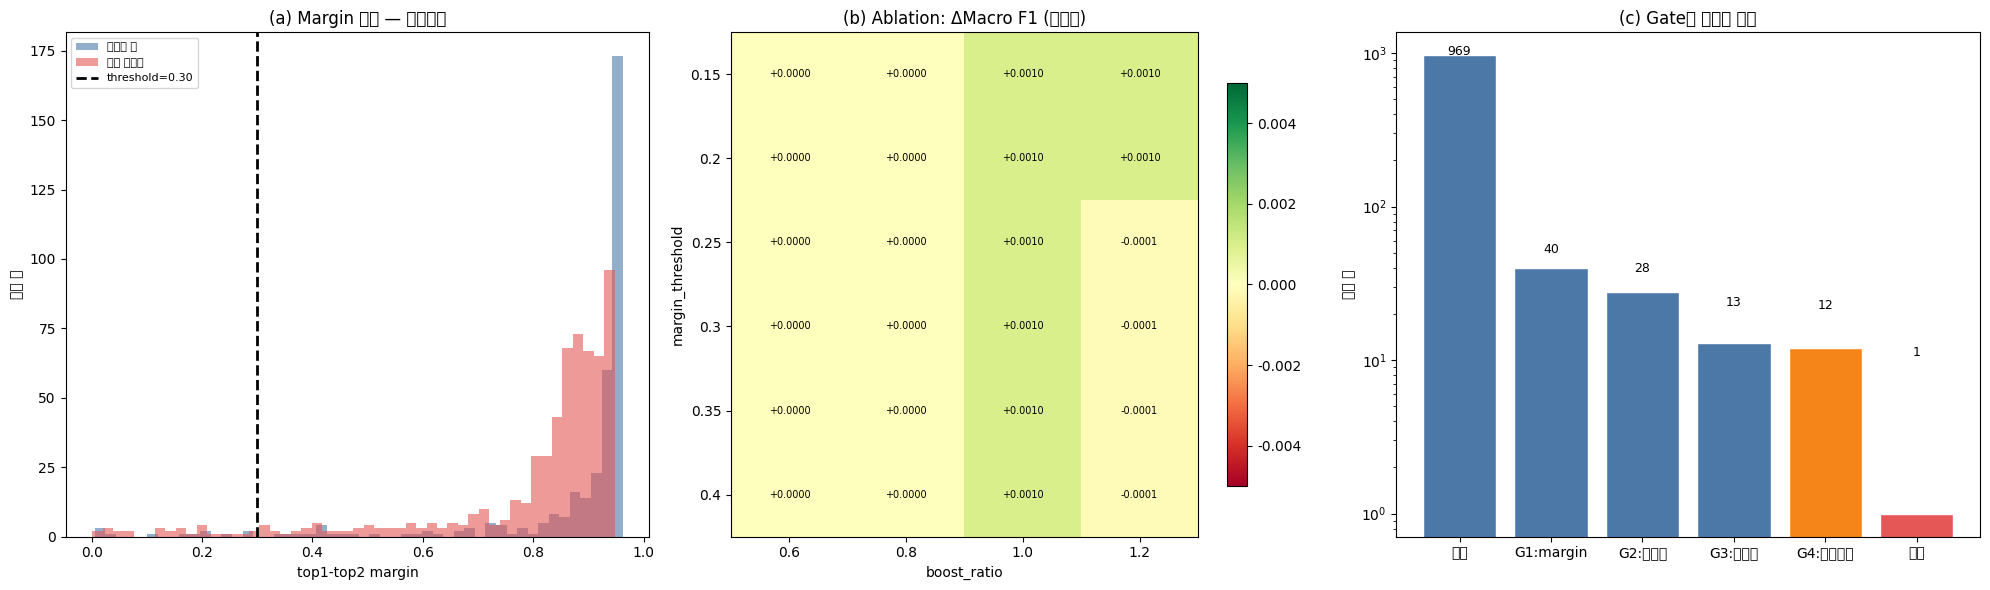

  → 저장: dktc_rule_postprocessing_v3.png


In [14]:
# ============================================================================
# 09. 시각화
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
]
font_path = None
for fc in font_candidates:
    if os.path.exists(fc):
        font_path = fc
        break
if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Margin 분포 + 타겟 혼동축 비율
ax = axes[0]
ax.hist(margins[~on_target_mask], bins=50, color="#4C78A8", alpha=0.6, label="비타겟 축")
ax.hist(margins[on_target_mask], bins=50, color="#E45756", alpha=0.6, label="타겟 혼동축")
ax.axvline(x=0.30, color="black", linestyle="--", linewidth=2, label="threshold=0.30")
ax.set_xlabel("top1-top2 margin")
ax.set_ylabel("샘플 수")
ax.set_title("(a) Margin 분포 — 혼동축별")
ax.legend(fontsize=8)

# (b) Ablation Heatmap
ax = axes[1]
pivot_data = pivot_f1.values
im = ax.imshow(pivot_data, cmap="RdYlGn", aspect="auto", vmin=-0.005, vmax=0.005)
ax.set_xticks(range(len(BOOST_RATIOS)))
ax.set_xticklabels([f"{v}" for v in BOOST_RATIOS])
ax.set_yticks(range(len(MARGIN_THRESHOLDS)))
ax.set_yticklabels([f"{v}" for v in MARGIN_THRESHOLDS])
ax.set_xlabel("boost_ratio")
ax.set_ylabel("margin_threshold")
ax.set_title("(b) Ablation: ΔMacro F1 (참고용)")
for i in range(len(MARGIN_THRESHOLDS)):
    for j in range(len(BOOST_RATIOS)):
        ax.text(
            j, i, f"{pivot_data[i, j]:+.4f}",
            ha="center", va="center", fontsize=7,
            color="white" if abs(pivot_data[i, j]) > 0.003 else "black"
        )
fig.colorbar(im, ax=ax, shrink=0.8)

# (c) 파이프라인 Gate 통과 수
ax = axes[2]
gate_names = ["전체", "G1:margin", "G2:혼동축", "G3:키워드", "G4:후보확정", "변경"]
gate_counts = [
    adj_log["n_total"],
    adj_log["n_gate1_margin"],
    adj_log["n_gate2_axis"],
    adj_log["n_gate3_rule_hit"],
    adj_log["n_candidate_hit"],
    adj_log["n_changed"],
]
colors = ["#4C78A8"] * 4 + ["#F58518", "#E45756"]
ax.bar(gate_names, gate_counts, color=colors, edgecolor="white")
ax.set_ylabel("샘플 수")
ax.set_title("(c) Gate별 필터링 현황")
for i, v in enumerate(gate_counts):
    ax.text(i, v + max(gate_counts)*0.01, str(v), ha="center", fontsize=9)
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("dktc_rule_postprocessing_v3.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → 저장: dktc_rule_postprocessing_v3.png")

In [15]:
# ============================================================================
# 10. 커버리지 분석 v3 — Net Boost Advantage
# ============================================================================
wrong_mask = baseline_preds != val_labels
wrong_indices = np.where(wrong_mask)[0]

print(f"전체 오분류 {len(wrong_indices)}건에 대한 Net Boost Advantage 분석:\n")

analysis_results = []
for idx in wrong_indices:
    true_label = int(val_labels[idx])
    pred_label = int(baseline_preds[idx])
    text = val_texts[idx]

    confusion_pair = frozenset({true_label, pred_label})
    is_on_axis = confusion_pair in TARGET_CONFUSION_AXES

    hits_true = count_keyword_hits(text, true_label)
    hits_pred = count_keyword_hits(text, pred_label)
    net_advantage = hits_true - hits_pred

    analysis_results.append({
        "idx": idx,
        "true_label": true_label,
        "pred_label": pred_label,
        "is_on_axis": is_on_axis,
        "hits_true": hits_true,
        "hits_pred": hits_pred,
        "net_advantage": net_advantage,
    })

df_coverage = pd.DataFrame(analysis_results)

on_axis_df = df_coverage[df_coverage["is_on_axis"]]
off_axis_df = df_coverage[~df_coverage["is_on_axis"]]

print(f"오분류 분류:")
print(f"  타겟 혼동축 위 : {len(on_axis_df)}건")
print(f"  비타겟 축      : {len(off_axis_df)}건 (v3도 기본적으로 이것은 직접 개입 안 함)")

if len(on_axis_df) > 0:
    n_positive = (on_axis_df["net_advantage"] > 0).sum()
    n_zero = (on_axis_df["net_advantage"] == 0).sum()
    n_negative = (on_axis_df["net_advantage"] < 0).sum()

    print(f"\n타겟 축 오분류 Net Boost Advantage:")
    print(f"  교정 가능 (advantage > 0)  : {n_positive}건 ({n_positive/len(on_axis_df)*100:.1f}%)")
    print(f"  효과 없음 (advantage == 0) : {n_zero}건 ({n_zero/len(on_axis_df)*100:.1f}%)")
    print(f"  악화 위험 (advantage < 0)  : {n_negative}건 ({n_negative/len(on_axis_df)*100:.1f}%)")

    print(f"\n혼동축별 교정 가능률:")
    for axis in TARGET_CONFUSION_AXES:
        ids = sorted(axis)
        axis_name = f"{LABEL_NAMES[ids[0]]}↔{LABEL_NAMES[ids[1]]}"
        axis_df = on_axis_df[
            on_axis_df.apply(lambda r: frozenset({r['true_label'], r['pred_label']}) == axis, axis=1)
        ]
        if len(axis_df) > 0:
            n_pos = (axis_df["net_advantage"] > 0).sum()
            print(f"  {axis_name:20s}: {n_pos}/{len(axis_df)} ({n_pos/len(axis_df)*100:.0f}%) 교정 가능")

bad_samples = on_axis_df[on_axis_df["net_advantage"] < 0]
if len(bad_samples) > 0:
    print(f"\n악화 위험 샘플 ({len(bad_samples)}건 — 키워드 개선 참고):")
    for _, row in bad_samples.head(5).iterrows():
        text_preview = str(val_texts[row["idx"]])[:100].replace("\n", " ")
        print(
            f"  [{row['idx']:4d}] 정답={LABEL_NAMES[row['true_label']]:8s} "
            f"예측={LABEL_NAMES[row['pred_label']]:8s} "
            f"hits_true={row['hits_true']} hits_pred={row['hits_pred']} | {text_preview}..."
        )

전체 오분류 68건에 대한 Net Boost Advantage 분석:

오분류 분류:
  타겟 혼동축 위 : 46건
  비타겟 축      : 22건 (v3도 기본적으로 이것은 직접 개입 안 함)

타겟 축 오분류 Net Boost Advantage:
  교정 가능 (advantage > 0)  : 3건 (6.5%)
  효과 없음 (advantage == 0) : 37건 (80.4%)
  악화 위험 (advantage < 0)  : 6건 (13.0%)

혼동축별 교정 가능률:
  협박↔갈취               : 1/14 (7%) 교정 가능
  갈취↔기타괴롭힘            : 2/24 (8%) 교정 가능
  직장내괴롭힘↔기타괴롭힘        : 0/8 (0%) 교정 가능

악화 위험 샘플 (6건 — 키워드 개선 참고):
  [ 127] 정답=기타괴롭힘    예측=갈취       hits_true=0 hits_pred=1 | 오 신발샀냐? [턴] 응. 전에 신던게 다 헤져서.부모님이 사주셨어. [턴] 니네 집 꽤 사나보다? 이런 신발도 잘 사주시고? [턴] 응.? 그런건 아닌데.그래도 신발은 오래 신는...
  [ 208] 정답=협박       예측=갈취       hits_true=0 hits_pred=2 | 김사장. 우리 그동안의 세월을 봐서 내가 많이 봐줬다. [턴] 한번만 더 시간을 주면 안되겠나? [턴] 김사장도 양심도 없지. 내가 땅파서 장사하나? [턴] 하지만 이자가 터무니 ...
  [ 262] 정답=협박       예측=갈취       hits_true=0 hits_pred=1 | 안녕하세요 [턴] 네 [턴] 혹시 이나연씨인가요? [턴] 네 맞아요 [턴] 왜그러시죠? [턴] 돈을 안갚으셨내요 [턴] 아 맞다 [턴] 내일까지 꼭 갚을게요 [턴] 오늘까지 갚으세...
  [ 595] 정답=협박       예측=갈취       hits_true=0 hits_pred=2 | 야 머하냐? [턴] 학원가려고. [턴] 돈 좀 있냐? [턴] 아니

In [ ]:
# ============================================================================
# 11. Kaggle 제출 전략 — 후처리 포함/미포함 동시 제출
# ============================================================================
def postprocess_for_submission(
    logits,
    texts,
    margin_threshold=0.35,
    boost_ratio=1.0,
):
    """
    Kaggle 제출용 후처리 함수.

    사용법:
        test_result = trainer.predict(test_dataset)
        test_logits = test_result.predictions
        preds_a = np.argmax(test_logits, axis=-1)  # 제출 A: 후처리 없음
        preds_b = postprocess_for_submission(test_logits, test_texts)  # 제출 B: 후처리 적용
    """
    adjusted_preds, _ = apply_rule_postprocessing_v3(
        logits=logits,
        texts=texts,
        margin_threshold=margin_threshold,
        boost_ratio=boost_ratio,
        topk_candidates=3,
        tie_break_boost=0.5,
    )
    return adjusted_preds

print("현재 검증셋 참고 성능 (⚠ 최종 확정 수치 아님):")
print(f"  원본 Macro F1     : {baseline_f1_macro:.4f}")
print(f"  후처리 Macro F1   : {adjusted_f1_macro:.4f}")
print(f"  Delta             : {adjusted_f1_macro - baseline_f1_macro:+.4f}")
print(f"  변경 건수          : {adj_log['n_changed']}")
print(f"\n⚠ 이 delta는 같은 validation에서 측정한 값입니다.")
print(f"  일반화 성능은 Kaggle public/private LB에서 확인해야 합니다.")
print(f"  반드시 후처리 없는 원본과 함께 제출하여 비교하세요.")


현재 검증셋 참고 성능 (⚠ 최종 확정 수치 아님):
  원본 Macro F1     : 0.9301
  후처리 Macro F1   : 0.9310
  Delta             : +0.0010
  변경 건수          : 1

⚠ 이 delta는 같은 validation에서 측정한 값입니다.
  일반화 성능은 Kaggle public/private LB에서 확인해야 합니다.
  반드시 후처리 없는 원본과 함께 제출하여 비교하세요.


In [17]:
# ============================================================================
# 12. 결과 저장
# ============================================================================
df_ablation.to_csv("dktc_rule_postprocessing_v3_ablation.csv", index=False)
print("dktc_rule_postprocessing_v3_ablation.csv 저장 완료")

rules_export = {class_name: patterns for class_name, patterns in KEYWORD_RULES.items()}
with open("dktc_keyword_rules_v3.json", "w", encoding="utf-8") as f:
    json.dump(rules_export, f, ensure_ascii=False, indent=2)
print("dktc_keyword_rules_v3.json 저장 완료")

config_export = {
    "version": "v3",
    "target_confusion_axes": [[int(x) for x in sorted(axis)] for axis in TARGET_CONFUSION_AXES],
    "default_margin_threshold": 0.30,
    "default_boost_ratio": 1.0,
    "default_topk_candidates": 3,
    "default_tie_break_boost": 0.5,
    "baseline_macro_f1": float(baseline_f1_macro),
    "postprocessed_macro_f1_on_val": float(adjusted_f1_macro),
    "delta_f1_on_val": float(adjusted_f1_macro - baseline_f1_macro),
    "note": "delta는 동일 validation 기준 참고값. 일반화 성능은 LB에서 확인 필요.",
}
with open("dktc_postprocessing_config_v3.json", "w") as f:
    json.dump(config_export, f, indent=2)
print("dktc_postprocessing_config_v3.json 저장 완료")

df_coverage.to_csv("dktc_net_boost_coverage_v3.csv", index=False)
print("dktc_net_boost_coverage_v3.csv 저장 완료")

print(f"\n{'=' * 70}")
print(f"규칙 기반 후처리 v3 분석 완료")
print(f"  Baseline Macro F1          : {baseline_f1_macro:.4f}")
print(f"  Postprocessed (val 참고)    : {adjusted_f1_macro:.4f}")
print(f"  Delta (val 참고)            : {adjusted_f1_macro - baseline_f1_macro:+.4f}")
print(f"  Gate 통과율                 : {adj_log['n_candidate_hit']}/{adj_log['n_total']}")
print(f"  예측 변경                   : {adj_log['n_changed']}건")
print(f"{'=' * 70}")

dktc_rule_postprocessing_v3_ablation.csv 저장 완료
dktc_keyword_rules_v3.json 저장 완료
dktc_postprocessing_config_v3.json 저장 완료
dktc_net_boost_coverage_v3.csv 저장 완료

규칙 기반 후처리 v3 분석 완료
  Baseline Macro F1          : 0.9301
  Postprocessed (val 참고)    : 0.9310
  Delta (val 참고)            : +0.0010
  Gate 통과율                 : 12/969
  예측 변경                   : 1건
